# CoTTA Adaptation on IDRiD with VisionFM (every-batch)


In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
# Download VisionFM weights (cached after first run)
from src.models.visionfm_download import download_visionfm_weights
weights_path = download_visionfm_weights(cache_dir="./cache/visionfm")
print(f"VisionFM weights cached at: {weights_path}")

Downloading...
From (original): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4
From (redirected): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4&confirm=t&uuid=b29b9c95-2e1e-4988-b174-4ffffea69a94
To: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
100%|██████████| 1.51G/1.51G [00:26<00:00, 57.7MB/s]

VisionFM weights cached at: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth


In [4]:
config = load_config('configs/method/cotta/idrid_visionfm.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Model:', config.model.name)
print('Output:', config.output_dir)
print('LR:', config.ctta.lr)
print('Confidence threshold:', config.ctta.confidence_threshold)
print('Adapt last N blocks:', config.ctta.adapt_last_n_blocks)
print('Normalize:', config.model.normalize_mean)

Dataset: idrid
Method: cotta
Model: visionfm
Output: ./outputs/cotta/idrid_visionfm/
LR: 0.0001
Confidence threshold: 0.3
Adapt last N blocks: 4
Normalize: [0.4237, 0.2609, 0.1284]


In [5]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-07-31 15:36:17,862 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: idrid
2026-07-31 15:36:17,863 - src.models.visionfm_download - INFO - VisionFM Fundus weights found at ./cache/visionfm/VFM_Fundus_weights.pth (cached)
2026-07-31 15:36:19,040 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-07-31 15:36:20,001 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-07-31 15:36:20,002 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-07-31 15:36:20,073 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-07-31 15:36:20,111 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-07-31 15:36:20,112 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-07-31 15:36:20,475 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-0

Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

2026-07-31 15:37:01,545 - src.evaluation.runner.single - INFO -   Adapt step 0: loss=0.2767, kl=0.2790, conf_samples=11, teacher_max_prob=0.7964


Adapting to idrid:  14%|█▍        | 1/7 [00:06<00:39,  6.65s/it, acc=0.3750, adaptations=1]

2026-07-31 15:37:05,195 - src.evaluation.runner.single - INFO -   Adapt step 1: loss=0.2082, kl=0.2102, conf_samples=11, teacher_max_prob=0.8295


...

Adapting to idrid:  86%|████████▌ | 6/7 [00:24<00:03,  3.80s/it, acc=0.3750, adaptations=6]

2026-07-31 15:37:21,421 - src.evaluation.runner.single - INFO -   Adapt step 6: loss=0.4554, kl=0.4524, conf_samples=6, teacher_max_prob=0.8791


Adapting to idrid: 100%|██████████| 7/7 [00:26<00:00,  3.77s/it, acc=0.1429, adaptations=7]

2026-07-31 15:37:21,476 - src.evaluation.runner.single - INFO - Evaluating after adaptation on idrid


2026-07-31 15:37:28,044 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.5062
2026-07-31 15:37:28,045 - src.evaluation.runner.single - INFO - Adaptations: 7/7
2026-07-31 15:37:28,090 - src.evaluation.runner.base - INFO - Results saved to outputs/cotta/idrid_visionfm/ctta_results.json


In [6]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

=== Results ===
Baseline QWK:        0.4957
Baseline Accuracy:   35.92%
Post-adapt QWK:      0.5062
Post-adapt Accuracy: 35.92%
Adaptations:          7/7
Adaptation rate:      100.00%
QWK change:           +0.0106
Accuracy change:      +0.00%


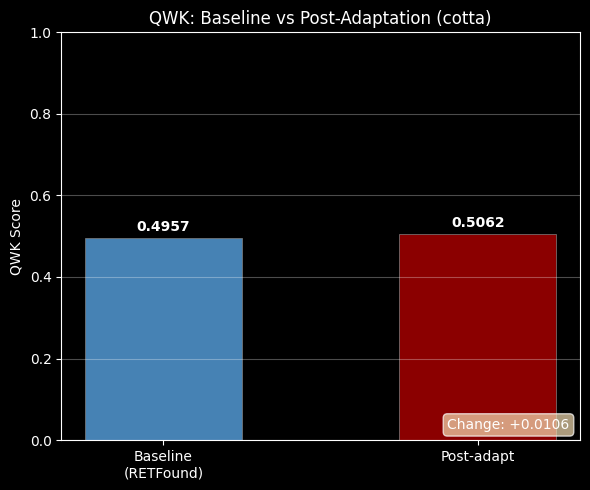

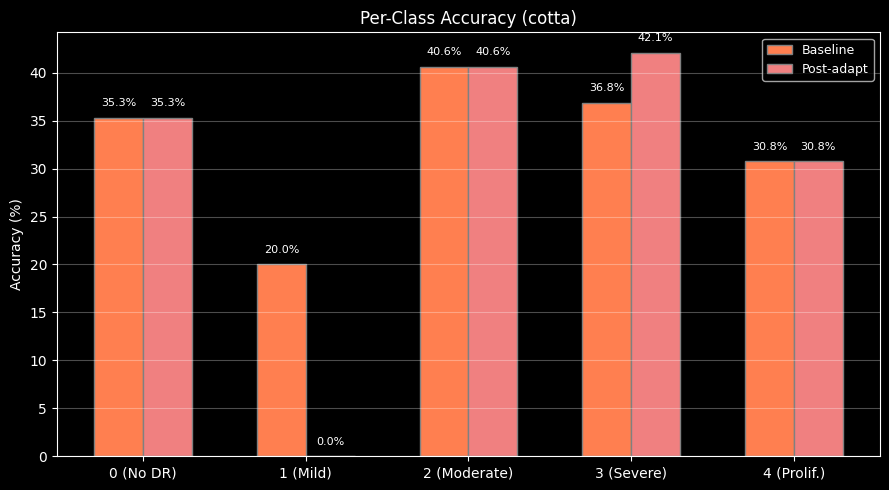

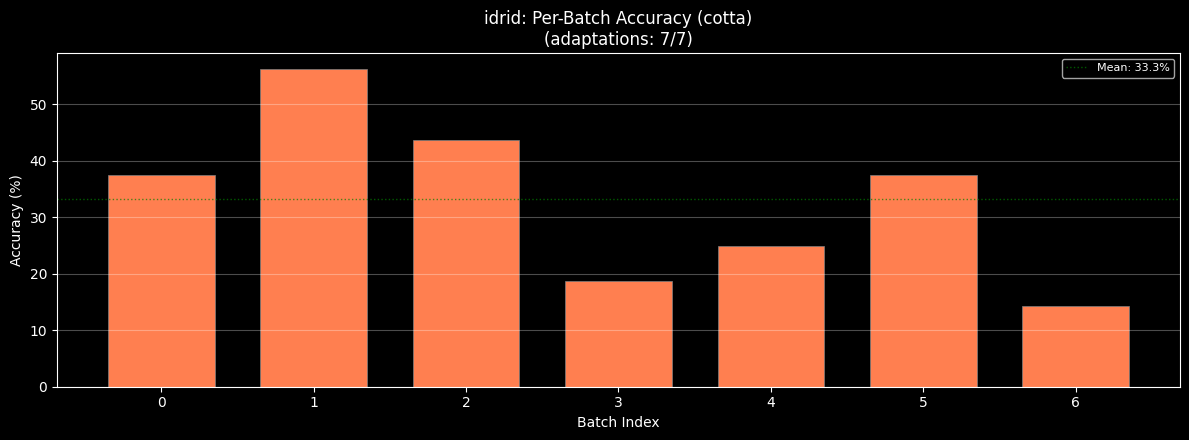

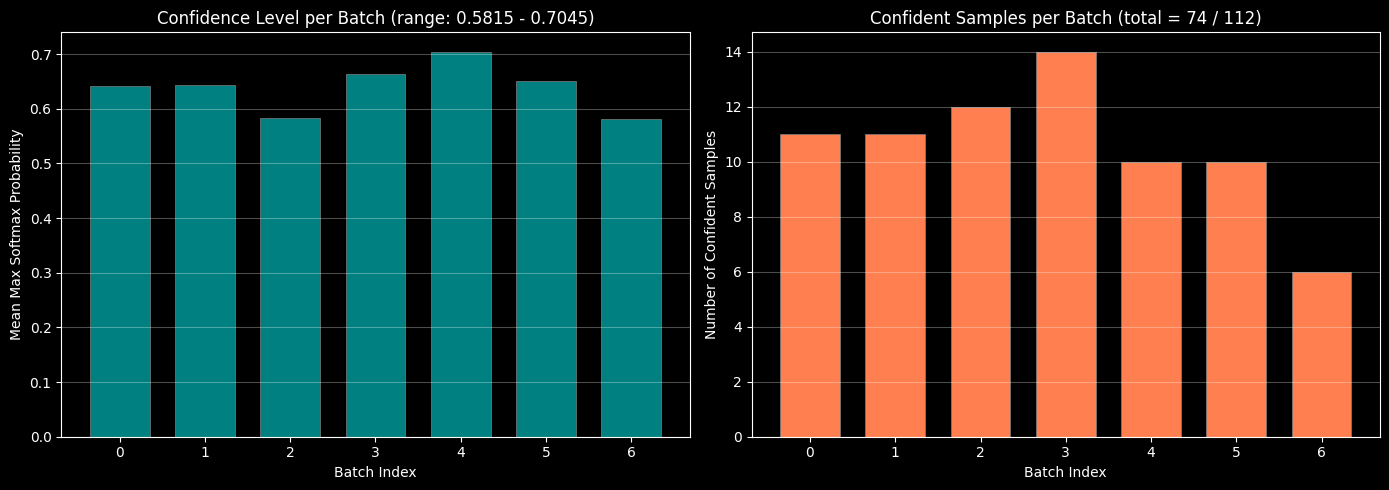

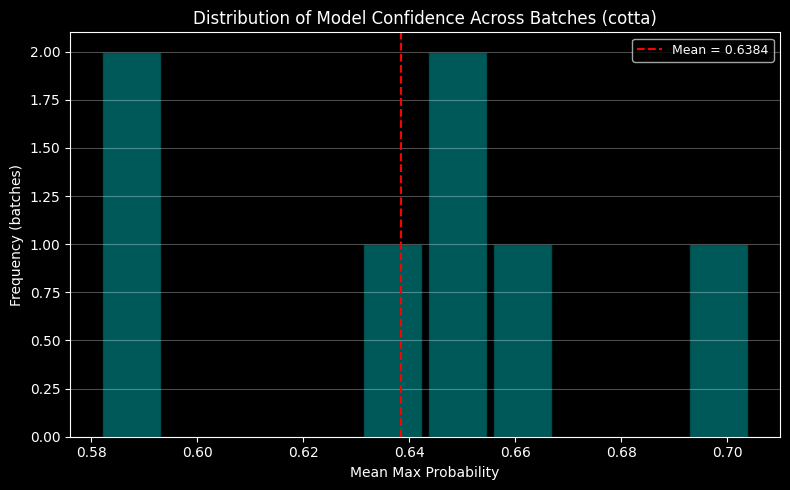

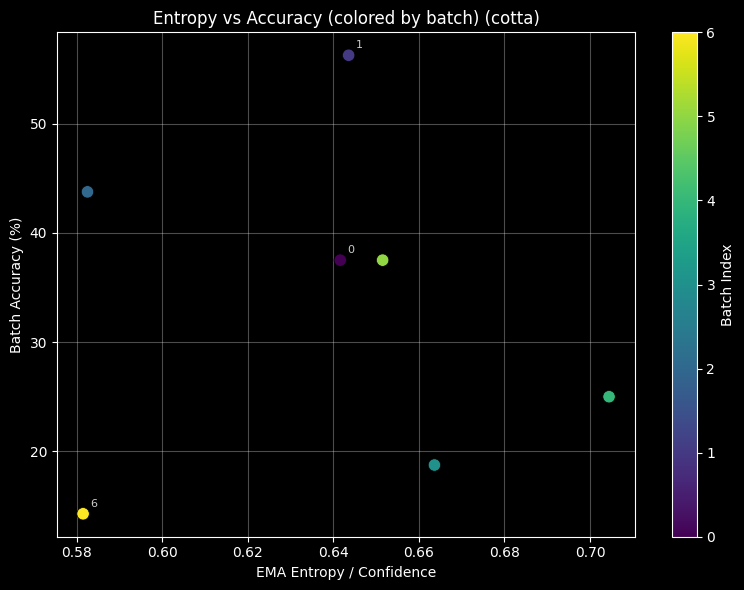

====================== CTTA Results (cotta) =====================
Baseline QWK:       0.4957
Post-adapt QWK:     0.5062
Adaptations:        7/7
Adaptation rate:    100.00%
QWK change:         +0.0106
Mean batch acc:     33.3%


In [7]:
from src.viz import (
    get_domain_data, plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)